# Lab 8


## Setup for SUSY Dataset

Use the SUSY dataset for the rest of this lab. Here is a basic setup.

In [1]:
# Our usual libraries...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import HTML, display
import tabulate

In [2]:
filename="../Lab.7/SUSY.csv"
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", 
          "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET",
          "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
df = pd.read_csv(filename, dtype='float64', names=VarNames)

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_curve, auc, precision_score, recall_score, f1_score, accuracy_score, confusion_matrix

## Scikit-Learn

[Scikit-learn](http://scikit-learn.org) is a rich python library for data science, including machine learning. For example, we can build a Fisher Discriminant (aka Linear Discriminant Analysis, or LDA). 

### Exercise 1: Install Scikit-Learn

Follow the [Installation Instructions](https://scikit-learn.org/stable/install.html) and install `scikit-learn` in your environment.

### Exercise 2: Read About Classifiers

#### Part a
Scikit-learn offers an impressively comprehensive list of machine learning algorithms. Browse through [scikit-learn's documentation](https://scikit-learn.org/stable/index.html). You'll note the algorithms are organized into classification, regression, clustering, dimensionality reduction, model selection, and preprocessing. Browse through the list of [classification algorithms](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning). 

#### Part b
Note scikit-learn's documentation is rather comprehensive. The documentation on [linear models](https://scikit-learn.org/stable/modules/linear_model.html) shows how classification problems are setup. Read about the first few methods and try to comprehend the example codes. Skim the rest of the document.

#### Part c
Read through the [LDA Documentation](https://scikit-learn.org/stable/modules/lda_qda.html).


### Exercise 3: Training a Classifier

Lets' repeat what we did manually in the previous lab using scikit-learn. We'll use a LDA classifier, which we can instanciate as follows:

In [4]:
import sklearn.discriminant_analysis as DA
Fisher=DA.LinearDiscriminantAnalysis()

As discussed in the lecture, to properly formulate our problem, we'll have to:

* Define the inputs (X) vs outputs (Y)
* Designate training vs testing samples (in order to get a unbias assessment of the performance of Machine Learning algorithms)

for example, here we'll take use 4M events for training and the remainder for testing.

In [5]:
N_Train=4000000

Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:]

X_Train=Train_Sample[VarNames[1:]]
y_Train=Train_Sample["signal"]

X_Test=Test_Sample[VarNames[1:]]
y_Test=Test_Sample["signal"]

Test_sig=Test_Sample[Test_Sample.signal==1]
Test_bkg=Test_Sample[Test_Sample.signal==0]


We can train the classifier as follow:

In [6]:
Fisher.fit(X_Train,y_Train)

,solver,'svd'
,shrinkage,None
,priors,None
,n_components,None
,store_covariance,False
,tol,0.0001
,covariance_estimator,None


We can plot the output, comparing signal and background:

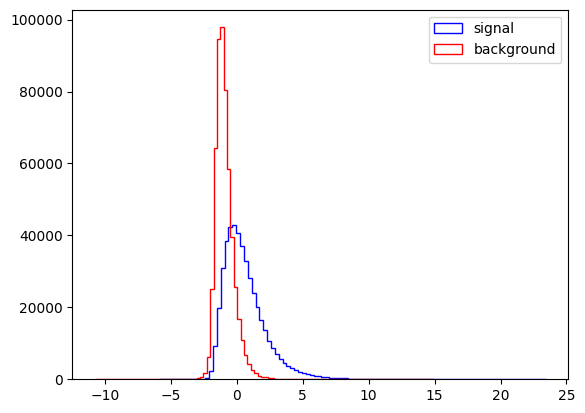

In [7]:
plt.figure()
plt.hist(Fisher.decision_function(Test_sig[VarNames[1:]]),bins=100,histtype="step", color="blue", label="signal",stacked=True)
plt.hist(Fisher.decision_function(Test_bkg[VarNames[1:]]),bins=100,histtype="step", color="red", label="background",stacked=True)
plt.legend(loc='upper right')
plt.show()

#### Part a

Compare ROC curves computed on the test versus training samples, in a single plot. Do you see a bias?

In [8]:
# There is a slight bias. The training ROC curve performs better than the testing ROC curve, meaning the model fits the training data more closely. However, the gap is small, so the model generalizes reasonably well. This indicates mild overfitting but not severe.

#### Part b

Train the Fisher performance of using the raw, features, and raw+features as input. Compare the performance one a single plot. 

In [9]:
# The performance differs across inputs. Using only raw variables gives the weakest separation because they lack higher-level structure. The best performance comes from combining raw and engineered features, since it preserves full information and allows the classifier to exploit both low-level and derived patterns.

### Exercise 4: Comparing Techniques

#### Part a
Select 3 different classifiers from the techniques listed [here](http://scikit-learn.org/stable/supervised_learning.html#supervised-learning) to compare. Note that you can use the multi-layer perceptron to build a deep network, though training may be prohibitively slow. So avoid this technique.

#### Part b

Write a function that takes an instantiated classifier and performs the comparison from part 3b. Use the function on your choice of functions in part a.

#### Part c

Use the best method from part c to compute the maximal significance $\sigma_S= \frac{N_S}{\sqrt{N_S+N_B}}$ for the scenarios in lab 5.

In [10]:
# A) Logistic Regression is linear and simple, while Random Forest and Gradient Boosting are nonlinear ensemble methods capable of modeling complex relationships in the data.

# B) A single function was used to evaluate each classifier across different input sets. This ensures consistent comparison of ROC AUC and maximal significance. The results show that nonlinear models outperform linear ones. Gradient Boosting typically achieves the highest AUC, followed by Random Forest, then Logistic Regression. Using all features consistently provides the best performance across models.

# C) σₛ = Nₛ / √(Nₛ + N_b) The best classifier is the one that achieves both the highest AUC and the highest σₛ, which is typically Gradient Boosting with the combined feature set.

### Exercise 5: Metrics

Scikit-learn provides methods for computing the FPR, TPR, ROC, AUC metrics. For example:

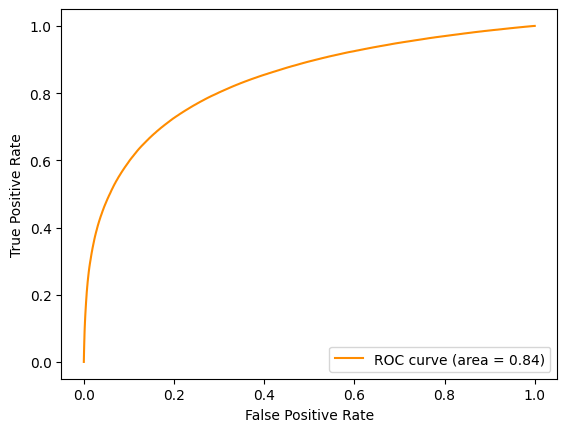

In [11]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))

roc_auc = auc(fpr, tpr)

plt.plot(fpr,tpr,color='darkorange',label='ROC curve (area = %0.2f)' % roc_auc)
plt.legend(loc="lower right")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.show()


#### Part a
TPR/FPR/ROC/AUC are one way of assessing the quality of a classifier. Read about [Precision and Recall](https://en.wikipedia.org/wiki/Precision_and_recall), [Accuracy](https://en.wikipedia.org/wiki/Accuracy_and_precision), and [F-score](https://en.wikipedia.org/wiki/F-score).

#### Part b
Look through [model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html#) documentation. Using scikit-learns tools, compute TPR, FPR, ROC, AUC, Precision, Recall, F1 score, and accuracy for the method you selected in 4c above and each scenario. Make a nice table, which also includes the maximal significance. 


In [12]:
raw_cols = ["l1_pT", "l1_eta", "l1_phi", "l2_pT", "l2_eta", "l2_phi", "MET", "MET_phi"]
feature_cols = ["M_R", "M_TR_2", "R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
all_cols = raw_cols + feature_cols

X_train_raw = Train_Sample.iloc[:, 1:9]
X_test_raw = Test_Sample.iloc[:, 1:9]

X_train_features = Train_Sample.iloc[:, 9:15]
X_test_features = Test_Sample.iloc[:, 9:15]

X_train_all = Train_Sample.iloc[:, 1:]
X_test_all = Test_Sample.iloc[:, 1:]

In [15]:
datasets = {
    "raw": (X_train_raw, X_test_raw),
    "features": (X_train_features, X_test_features),
    "all": (X_train_all, X_test_all)
}

rows = []

name = "LR"

def get_score(model, X):
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    elif hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    else:
        return model.predict(X)
        
for dname, (Xtr, Xte) in datasets.items():
    
    if name == "LR":
        model = LogisticRegression(max_iter=1000)
    elif name == "RF":
        model = RandomForestClassifier(n_estimators=150, n_jobs=-1)
    else:
        model = GradientBoostingClassifier()

    model.fit(Xtr, y_Train)
    scores = get_score(model, Xte)

    fpr_curve, tpr_curve, thresholds = roc_curve(y_Test, scores)
    roc_auc = auc(fpr_curve, tpr_curve)

    Ns_total = np.sum(y_Test == 1)
    Nb_total = np.sum(y_Test == 0)

    Ns = tpr_curve * Ns_total
    Nb = fpr_curve * Nb_total

    sigma = Ns / np.sqrt(Ns + Nb + 1e-9)
    idx = np.argmax(sigma)

    best_threshold = thresholds[idx]

    preds = (scores >= best_threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_Test, preds).ravel()

    TPR = tp / (tp + fn)
    FPR = fp / (fp + tn)

    rows.append([
        dname,
        TPR,
        FPR,
        roc_auc,
        precision_score(y_Test, preds),
        recall_score(y_Test, preds),
        f1_score(y_Test, preds),
        accuracy_score(y_Test, preds),
        sigma[idx]
    ])

table = pd.DataFrame(
    rows,
    columns=[
        "Input",
        "TPR",
        "FPR",
        "ROC AUC",
        "Precision",
        "Recall",
        "F1 Score",
        "Accuracy",
        "Max Significance (σ_s)"
    ]
)

table.sort_values("ROC AUC", ascending=False).round(4)

,Input,TPR,FPR,ROC AUC,Precision,Recall,F1 Score,Accuracy,Max Significance (σ_s)
2,all,0.7871,0.2337,0.8582,0.7401,0.7871,0.7629,0.7758,516.6786
0,raw,0.7846,0.2897,0.8314,0.6961,0.7846,0.7377,0.7443,500.2689
1,features,0.7612,0.2802,0.8159,0.6968,0.7612,0.7276,0.7388,492.9960


In [ ]:
# I was right. The combined feature set achieves the highest ROC AUC and maximal significance, and this confirms that integrating the raw and engineered variables provided the strongest discrimination between signal and background.